In [1]:
from edn_popdyn.paths import (
    FIGURES_DIR, STATS_CSV_DIR,
)

In [2]:
from edn_popdyn import colors as pal

# 1.1 — Psychometric effects of cues on categorization

Fit four-parameter logistic curves per cue condition, extract inflection points, and quantify cue A / cue B shifts across birds and sessions.

In [3]:
import os
import sys
import zipfile
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.autonotebook import tqdm

from scipy.stats import wilcoxon, mannwhitneyu
from sklearn.linear_model import LogisticRegression

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'

from cdcp.experiment_info import subjects
from cdcp.behavior.psychometric import FourParameterLogistic, fit_FourParameterLogistic

/tmp/ipykernel_1288179/3361728139.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## 0) Import data

In [4]:
from edn_popdyn.paths import CDCP_BEHAVIOR_DFS
DATA_PATH = str(CDCP_BEHAVIOR_DFS)
behav_data = {}

for subj in subjects:
    subj_path = os.path.join(DATA_PATH, f"{subj}.pickle")

    if os.path.exists(subj_path):
        print(f"Loading {subj_path}...")

        try:

            with zipfile.ZipFile(subj_path, "r") as zip_file:

                with zip_file.open(zip_file.namelist()[0]) as file:
                    df = pickle.load(file)

            if isinstance(df, pd.DataFrame) and "time" in df.columns:
                df["time"] = pd.to_datetime(df["time"], errors="coerce")
                df.set_index("time", inplace=True)

            df.dropna(inplace=True)
            behav_data[subj] = df

        except Exception as e:
            print(f"Error loading {subj_path}: {e}")

    else:
        print(f"File not found: {subj_path}")

Loading /mnt/cube/jugorman/EDNpopdyn/data/behavior/subject_behavior_dfs/B1174.pickle...
Loading /mnt/cube/jugorman/EDNpopdyn/data/behavior/subject_behavior_dfs/B1426.pickle...
Loading /mnt/cube/jugorman/EDNpopdyn/data/behavior/subject_behavior_dfs/B1170.pickle...
Loading /mnt/cube/jugorman/EDNpopdyn/data/behavior/subject_behavior_dfs/B1432.pickle...
Loading /mnt/cube/jugorman/EDNpopdyn/data/behavior/subject_behavior_dfs/B1437.pickle...
Loading /mnt/cube/jugorman/EDNpopdyn/data/behavior/subject_behavior_dfs/B1433.pickle...
Loading /mnt/cube/jugorman/EDNpopdyn/data/behavior/subject_behavior_dfs/B1597.pickle...
Loading /mnt/cube/jugorman/EDNpopdyn/data/behavior/subject_behavior_dfs/B1427.pickle...
Loading /mnt/cube/jugorman/EDNpopdyn/data/behavior/subject_behavior_dfs/B1188.pickle...
Loading /mnt/cube/jugorman/EDNpopdyn/data/behavior/subject_behavior_dfs/B1244.pickle...
Loading /mnt/cube/jugorman/EDNpopdyn/data/behavior/subject_behavior_dfs/B1590.pickle...
Loading /mnt/cube/jugorman/EDNpo

In [5]:
{i:len(behav_data[i]) for i in behav_data.keys()}

{'B1174': 355822,
 'B1426': 394956,
 'B1170': 520304,
 'B1432': 769387,
 'B1437': 87702,
 'B1433': 173287,
 'B1597': 33216,
 'B1427': 396727,
 'B1188': 74724,
 'B1244': 235092,
 'B1590': 170889,
 'B1399': 1436,
 'B1591': 142534,
 'B1252': 488,
 'B1110': 112785,
 'B1390': 130094,
 'B1248': 91821,
 'B1593': 150831,
 'B1595': 98607,
 'B1276': 170278}

In [6]:
np.sum([len(behav_data[i]) for i in behav_data.keys()])

np.int64(4110980)

In [7]:
behav_data[subjects[0]]

,session,index,type_,stimulus,class_,response,correct,rt,reward,punish,...,left_stim,right_stim,interpolation_point,prob_cue,prob_cued_no_cue,data_file,response_bool,interpolation,pos_bin,cue_direction
time,,,,,,,,,,,,,,,,,,,,,
2019-03-07 14:02:51.536058,1,0,normal,/home/bird/opdat/B1174/stimuli/AE/NC/NC_AE_127...,L,R,False,0.719002,False,True,...,A,E,127,0.0,0.0,/mnt/cube/RawData/Magpi/B1174/B1174_trialdata_...,1,AE,24,N
2019-03-07 14:03:04.862672,1,2,normal,/home/bird/opdat/B1174/stimuli/AE/NC/NC_AE_127...,L,L,True,0.797104,False,False,...,A,E,127,0.0,0.0,/mnt/cube/RawData/Magpi/B1174/B1174_trialdata_...,0,AE,24,N
2019-03-07 14:03:11.852305,1,3,normal,/home/bird/opdat/B1174/stimuli/AE/NC/NC_AE_127...,L,R,False,0.749623,False,True,...,A,E,127,0.0,0.0,/mnt/cube/RawData/Magpi/B1174/B1174_trialdata_...,1,AE,24,N
2019-03-07 14:03:24.611050,1,5,normal,/home/bird/opdat/B1174/stimuli/AE/NC/NC_AE_127...,L,L,True,0.423042,False,False,...,A,E,127,0.0,0.0,/mnt/cube/RawData/Magpi/B1174/B1174_trialdata_...,0,AE,24,N
2019-03-07 14:50:49.114463,1,0,normal,/home/bird/opdat/B1174/stimuli/AE/NC/NC_AE_000...,R,R,True,1.137472,True,False,...,A,E,0,0.0,0.0,/mnt/cube/RawData/Magpi/B1174/B1174_trialdata_...,1,AE,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-05 13:12:33.980868,53,8,normal,/home/bird/opdat/B1174/stimuli/AG/CR1/CR1_AG_0...,R,R,True,0.734247,False,False,...,A,G,58,0.8,0.2,/mnt/cube/RawData/Magpi/B1174/B1174_trialdata_...,1,AG,11,R
2020-03-05 13:12:39.303920,53,9,normal,/home/bird/opdat/B1174/stimuli/CE/CL0/CL0_CE_0...,R,R,True,0.906224,False,False,...,C,E,18,0.8,0.2,/mnt/cube/RawData/Magpi/B1174/B1174_trialdata_...,1,CE,4,L
2020-03-05 13:12:44.480245,53,10,normal,/home/bird/opdat/B1174/stimuli/AG/CL0/CL0_AG_0...,L,R,False,1.092412,False,True,...,A,G,96,0.8,0.2,/mnt/cube/RawData/Magpi/B1174/B1174_trialdata_...,1,AG,19,L


## 1) Fit four-parameter logistic model across cues

In [8]:
from cdcp.behavior.psychometric import FourParameterLogistic, fit_FourParameterLogistic

$$
logistic(x) = d + \frac{a-d}{1+(\frac{x}{c})^b}
$$

$$
logistic(x) = max. + \frac{min.-max.}{1+(\frac{x}{inflection})^{slope}}
$$

Where 
- $a$ is the minimum value that can be obtained
- $b$ is Hill’s slope of the curve (i.e. this is related to the steepness of the curve at point c)
- $c$ is the point of inflection (i.e. the point on the S shaped curve halfway between a and d)
- $d$ is the maximum value that can be obtained

In [9]:
interp_range = np.arange(128)

In [10]:
nex = 100000
fit_df = pd.DataFrame(
    columns=[
        "bird",
        "cue",
        "n_points",
        "_min",
        "_max",
        "_inflection",
        "_slope",
        "model",
        "y_interp",
        "r_squared",
    ]
)

for bird in tqdm(subjects):

    behav_data_subject = behav_data[bird]
    if len(behav_data_subject) < nex:
        behav_data_subject = behav_data_subject[20000:]
    behav_data_subject = behav_data_subject[-nex:]
    for cue_id in behav_data_subject.cue_id.unique():
        if cue_id == "N":
            continue

        cue_df = behav_data_subject[behav_data_subject.cue_id == cue_id]
        interp_points = cue_df.interpolation_point.values.astype("float32")
        response_points = cue_df.response_bool.values.astype("float32")

        (
            (_min, _max, _inflection, _slope),
            results_logistic,
            y_model,
            r_squared,
        ) = fit_FourParameterLogistic(interp_points, response_points)

        y_interp = FourParameterLogistic(
            {"_min": _min, "_max": _max, "inflection": _inflection, "slope": _slope},
            interp_range,
        )

        fit_df.loc[len(fit_df)] = [
            bird,
            cue_id,
            len(cue_df),
            _min,
            _max,
            _inflection,
            _slope,
            results_logistic,
            y_interp,
            r_squared,
        ]

  0%|          | 0/20 [00:00<?, ?it/s]

In [11]:
fit_df

,bird,cue,n_points,_min,_max,_inflection,_slope,model,y_interp,r_squared
0,B1174,NC,16290,0.890283,0.129460,60.470323,9.466683,<lmfit.minimizer.MinimizerResult object at 0x7...,"[0.8902834986931376, 0.8902834986931376, 0.890...",0.459241
1,B1174,CR1,19844,0.941454,0.156043,64.558546,9.958677,<lmfit.minimizer.MinimizerResult object at 0x7...,"[0.9414535142655865, 0.9414535142655865, 0.941...",0.370165
2,B1174,CR0,20053,0.931184,0.147122,63.864944,10.136763,<lmfit.minimizer.MinimizerResult object at 0x7...,"[0.9311838631156966, 0.9311838631156966, 0.931...",0.466434
3,B1174,CL1,20196,0.867947,0.066240,57.484838,9.967098,<lmfit.minimizer.MinimizerResult object at 0x7...,"[0.8679465868476575, 0.8679465868476575, 0.867...",0.375754
4,B1174,CN,4024,0.903822,0.095681,61.705135,8.336909,<lmfit.minimizer.MinimizerResult object at 0x7...,"[0.9038215886500076, 0.9038215886500067, 0.903...",0.492469
...,...,...,...,...,...,...,...,...,...,...
103,B1276,CR0,19856,0.146134,0.952717,64.009615,14.783335,<lmfit.minimizer.MinimizerResult object at 0x7...,"[0.14613375785553162, 0.14613375785553162, 0.1...",0.542653
104,B1276,CR1,20389,0.217842,0.964009,62.010800,11.356169,<lmfit.minimizer.MinimizerResult object at 0x7...,"[0.21784220813748523, 0.21784220813748523, 0.2...",0.402496
105,B1276,CL0,19855,0.047516,0.919949,67.758885,13.931536,<lmfit.minimizer.MinimizerResult object at 0x7...,"[0.04751576848336925, 0.04751576848336925, 0.0...",0.618021
106,B1276,NC,16001,0.067455,0.939356,65.738703,11.589483,<lmfit.minimizer.MinimizerResult object at 0x7...,"[0.06745485573365873, 0.06745485573365873, 0.0...",0.620752


## 1) One bird

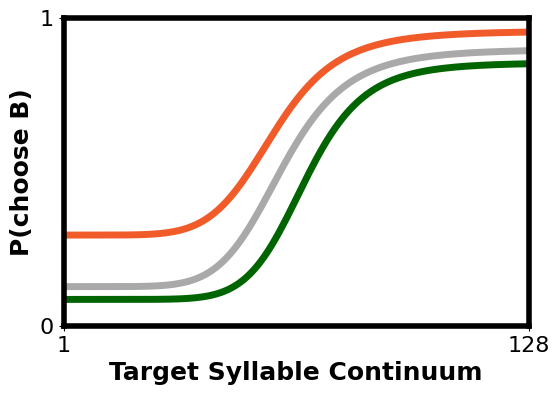

In [12]:
bird_id = 'B1248'
bird_df = fit_df[fit_df["bird"] == bird_id]

cue_colors = {
    "NC": "darkgray",
    "CR": pal.cue_cr,
    "CL": "darkgreen",
}

cue_labels = {
    "NC": "No Cue",
    "CL": "Cue A",
    "CR": "Cue B",
}

cue_groups = {"NC": [], "CL": [], "CR": []}

for _, row in bird_df.iterrows():
    cue = row["cue"]
    if cue in ["CL0", "CL1"]:
        cue_groups["CL"].append(row["y_interp"])
    elif cue in ["CR0", "CR1"]:
        cue_groups["CR"].append(row["y_interp"])
    elif cue == "NC":
        cue_groups["NC"].append(row["y_interp"])

avg_curves = {}
for cue, curves in cue_groups.items():
    if curves:
        avg_curves[cue] = np.mean(np.vstack(curves), axis=0)

interp_range = np.linspace(1, 128, len(avg_curves["NC"]))

fig, ax = plt.subplots(figsize=(6, 4))

for cue, y_interp in avg_curves.items():
    ax.plot(interp_range, y_interp, label=cue_labels[cue], color=cue_colors[cue], linewidth=5)

ax.set_xlabel("Target Syllable Continuum", fontsize=18, fontweight="bold")
ax.set_ylabel("P(choose B)", fontsize=18, fontweight="bold")
ax.set_ylim(0, 1)
ax.set_xlim(1, 128)

ax.set_xticks([1, 128])
ax.set_yticks([0, 1])

for spine in ax.spines.values():
    spine.set_linewidth(4)

ax.xaxis.set_tick_params(labelsize=16)
ax.yaxis.set_tick_params(labelsize=16)

plt.rcParams["font.family"] = "sans-serif"

plt.show()

In [13]:
bird_id = "B1248"
SESSION_COL_CANDIDATES = ["session","date","block","sess"]
CONT_MIN, CONT_MAX = 1, 128

def _orient_and_clean(y):
    y = np.asarray(y, float)
    finite = np.isfinite(y)
    if finite.mean() < 0.7:
        return None
    if not finite.all():
        x = np.arange(len(y))
        y[~finite] = np.interp(x[~finite], x[finite], y[finite])

    xs = np.linspace(0,1,len(y))
    if np.isfinite(np.corrcoef(xs, y)[0,1]) and np.corrcoef(xs, y)[0,1] < 0:
        y = 1.0 - y
    return np.clip(y, 0, 1)

def threshold_50(y):
    y = np.asarray(y, float)
    above = y >= 0.5
    idx = np.where(np.diff(above.astype(int)) != 0)[0]
    if idx.size == 0:
        return np.nan
    i = int(idx[0])
    x0 = CONT_MIN + (CONT_MAX - CONT_MIN) * (i    )/(len(y)-1)
    x1 = CONT_MIN + (CONT_MAX - CONT_MIN) * (i + 1)/(len(y)-1)
    y0, y1 = y[i], y[i+1]
    if y1 == y0:
        return float(x0)
    frac = (0.5 - y0) / (y1 - y0)
    return float(x0 + frac*(x1 - x0))

def hl_median_diff(x, y, max_pairs=100000, seed=0):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float); y = np.asarray(y, float)
    n_pairs = x.size * y.size
    if n_pairs <= max_pairs:
        diffs = x[:,None] - y[None,:]
        return float(np.nanmedian(diffs))
    ix = rng.integers(0, x.size, size=max_pairs)
    iy = rng.integers(0, y.size, size=max_pairs)
    return float(np.nanmedian(x[ix] - y[iy]))

sub = fit_df.loc[fit_df["bird"] == bird_id].copy()
if sub.empty:
    raise ValueError(f"No rows for bird {bird_id} in fit_df.")

session_col = None
for c in SESSION_COL_CANDIDATES:
    if c in sub.columns:
        session_col = c
        break

cue_map = {"NC":"NC","CL0":"CL","CL1":"CL","CR0":"CR","CR1":"CR"}
sub["cue3"] = sub["cue"].map(cue_map)

if session_col is not None:
    print(f"[Audit] Counts per session for {bird_id}:")
    counts = sub.groupby([session_col,"cue3"], dropna=False).size().unstack(fill_value=0)
    print(counts.sort_index())

t50_rows = []
for _, r in sub.iterrows():
    cue3 = r["cue3"]
    if cue3 not in ("NC","CL","CR"):
        continue

    if "_inflection" in sub.columns and np.isfinite(r.get("_inflection", np.nan)):
        t50 = float(r["_inflection"])
    else:
        y = _orient_and_clean(r["y_interp"])
        if y is None:
            continue
        t50 = threshold_50(y)
    if np.isfinite(t50):
        t50_rows.append((cue3, t50))

if len(t50_rows) == 0:
    raise ValueError("No usable thresholds found (check y_interp/_inflection).")

t50_df = pd.DataFrame(t50_rows, columns=["cue3","T50"])
nc = t50_df.loc[t50_df["cue3"]=="NC","T50"].to_numpy()
cl = t50_df.loc[t50_df["cue3"]=="CL","T50"].to_numpy()
cr = t50_df.loc[t50_df["cue3"]=="CR","T50"].to_numpy()

def _summ(name, a, b):
    if a.size >= 3 and b.size >= 3:
        U, p = mannwhitneyu(a, b, alternative="two-sided")
        hl = hl_median_diff(a, b)
        print(f"{name}: nA={a.size}, nB={b.size}, "
              f"medA={np.median(a):.2f}, medB={np.median(b):.2f}, "
              f"HL(A−B)={hl:.2f}; Mann–Whitney U={U:.0f}, p={p:.3g}")
    else:
        print(f"{name}: not enough samples (A={a.size}, B={b.size}).")

print(f"\n[Unpaired across rows for {bird_id}] Threshold (P=0.5) comparisons:")
_summ("CL vs NC (Δ<0 = shift toward A)", cl, nc)
_summ("CR vs NC (Δ<0 = shift toward A)", cr, nc)


[Unpaired across rows for B1248] Threshold (P=0.5) comparisons:
CL vs NC (Δ<0 = shift toward A): not enough samples (A=2, B=1).
CR vs NC (Δ<0 = shift toward A): not enough samples (A=2, B=1).


## 3) All birds

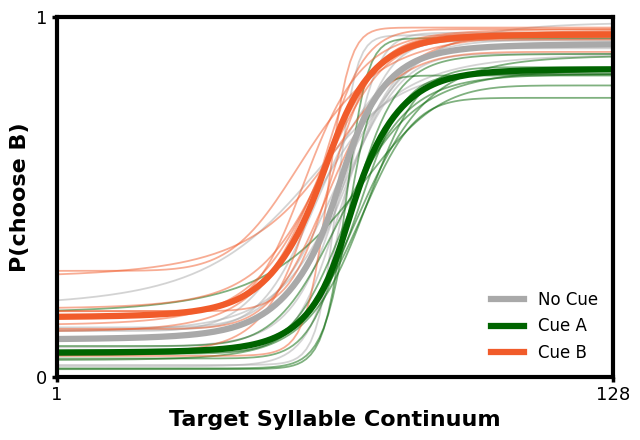

Saved to: /mnt/cube/jugorman/EDNpopdyn/for_github/figures/psychometric_curves.svg
=== Psychometric summary (per-bird) ===
    bird    AUC_NC     T50_NC    AUC_CL     T50_CL    AUC_CR     T50_CR  \
0  B1170  0.512615  65.324079  0.395083  72.624606  0.589170  58.863575   
1  B1248  0.522509  60.168923  0.445518  68.225722  0.647052  51.702111   
2  B1597  0.478509  66.914079  0.413333  68.318117  0.553612  59.628556   
3  B1595  0.539853  63.681955  0.427258  71.817448  0.539761  62.679667   
4  B1188  0.570750  55.329682  0.488875  68.407557  0.612834  56.425781   
5  B1244  0.503293  66.030412  0.427915  70.824339  0.580429  58.879164   
6  B1276  0.482501  66.651535  0.442330  69.271574  0.569061  62.408212   
7  B1426  0.504506  65.609737  0.418735  72.447347  0.570586  58.900696   
8  B1432  0.488908  64.990564  0.463987  67.189845  0.527138  62.721425   
9  B1593  0.538987  60.794226  0.430977  69.248577  0.604432  56.248500   

   ΔAUC_CR-NC  ΔAUC_NC-CL  ΔT50_CR-NC  ΔT50_CL-NC  


/tmp/ipykernel_1288179/1426258227.py:103: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, xx))


In [14]:
birds = ["B1170", "B1248", "B1597", "B1595", "B1188", "B1244", "B1276", "B1426", "B1432", "B1593"]
cue_map   = {"NC": "NC", "CL0": "CL", "CL1": "CL", "CR0": "CR", "CR1": "CR"}
cue_order = ["NC","CL","CR"]
cue_colors = {"NC":"darkgray", "CL":"darkgreen", "CR":pal.cue_cr}
cue_labels = {"NC":"No Cue", "CL":"Cue A", "CR":"Cue B"}

def _mean_stack(curves):
    if len(curves) == 0: return None
    A = np.vstack(curves)
    return np.nanmean(A, axis=0)

bird_curves = {b:{c:None for c in cue_order} for b in birds}
for b in birds:
    sub = fit_df[fit_df["bird"]==b].copy()

    grouped = {"NC":[], "CL":[], "CR":[]}
    for _, row in sub.iterrows():
        raw_c = row["cue"]
        if raw_c not in cue_map:
            continue
        c = cue_map[raw_c]
        y = np.asarray(row["y_interp"], float)
        grouped[c].append(y)
    for c in cue_order:
        bird_curves[b][c] = _mean_stack(grouped[c])

lengths = []
for b in birds:
    for c in cue_order:
        if bird_curves[b][c] is not None:
            lengths.append(len(bird_curves[b][c]))
if len(lengths)==0:
    raise ValueError("No curves found for selected birds.")
L = int(np.median(lengths))
def _trim_or_pad(y, L):
    y = np.asarray(y, float)
    if len(y) == L: return y
    if len(y) > L:  return y[:L]

    pad = np.full(L-len(y), y[-1] if len(y)>0 else np.nan)
    return np.r_[y, pad]
for b in birds:
    for c in cue_order:
        if bird_curves[b][c] is not None:
            bird_curves[b][c] = _trim_or_pad(bird_curves[b][c], L)

for b in birds:
    y_nc = bird_curves[b]["NC"]
    if y_nc is None:
        continue

    w = max(5, L//10)
    slope_sign = np.nanmean(y_nc[-w:]) - np.nanmean(y_nc[:w])
    if slope_sign < 0:
        for c in cue_order:
            y = bird_curves[b][c]
            if y is not None:
                bird_curves[b][c] = y[::-1]

x = np.linspace(1, 128, L)

grand = {}
for c in cue_order:
    stack = [bird_curves[b][c] for b in birds if bird_curves[b][c] is not None]
    grand[c] = np.nanmean(np.vstack(stack), axis=0) if len(stack) else None

fig, ax = plt.subplots(figsize=(6.5, 4.5))

for c in cue_order:
    for b in birds:
        y = bird_curves[b][c]
        if y is None:
            continue
        ax.plot(x, y, color=cue_colors[c], linewidth=1.3, alpha=0.5)

for c in cue_order:
    if grand[c] is not None:
        ax.plot(x, grand[c], color=cue_colors[c], linewidth=4.5, label=cue_labels[c])

ax.set_xlabel("Target Syllable Continuum", fontsize=16, fontweight="bold")
ax.set_ylabel("P(choose B)", fontsize=16, fontweight="bold")
ax.set_ylim(0, 1)
ax.set_xlim(x[0], x[-1])
ax.set_xticks([x[0], x[-1]])
ax.set_yticks([0, 1])

for spine in ax.spines.values():
    spine.set_linewidth(3)
ax.tick_params(labelsize=13, width=2.5)
ax.legend(frameon=False, fontsize=12, loc="lower right")
plt.tight_layout()
plt.show()

out_path = f"{FIGURES_DIR}/psychometric_curves.svg"

fig.savefig(out_path, format="svg", bbox_inches="tight")

print("Saved to:", out_path)

def auc01(y):

    xx = np.linspace(0, 1, len(y))
    return float(np.trapz(y, xx))

def threshold_50(x, y):

    y = np.asarray(y, float)
    above = y >= 0.5
    idx = np.where(np.diff(above.astype(int)) != 0)[0]
    if idx.size == 0:
        return np.nan
    i = idx[0]

    x0, x1 = x[i], x[i+1]
    y0, y1 = y[i], y[i+1]
    if y1 == y0:
        return float(x0)
    frac = (0.5 - y0) / (y1 - y0)
    return float(x0 + frac * (x1 - x0))

records = []
for b in birds:
    row = {"bird": b}
    for c in cue_order:
        y = bird_curves[b][c]
        row[f"AUC_{c}"] = np.nan if y is None else auc01(y)
        row[f"T50_{c}"] = np.nan if y is None else threshold_50(x, y)
    records.append(row)
stats_df = pd.DataFrame(records)

def paired_wilcoxon(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if np.sum(mask) < 3:
        return np.nan, np.nan, np.sum(mask)
    W, p = wilcoxon(a[mask], b[mask])
    return float(W), float(p), int(np.sum(mask))

W_cr_auc, p_cr_auc, n_cr_auc = paired_wilcoxon(stats_df["AUC_CR"].values, stats_df["AUC_NC"].values)
W_cl_auc, p_cl_auc, n_cl_auc = paired_wilcoxon(stats_df["AUC_CL"].values, stats_df["AUC_NC"].values)

def mean_sem(x):
    x = x[np.isfinite(x)]
    if x.size == 0: return np.nan, np.nan
    return float(np.mean(x)), float(np.std(x, ddof=1)/np.sqrt(x.size))

stats_df["ΔAUC_CR-NC"] = stats_df["AUC_CR"] - stats_df["AUC_NC"]
stats_df["ΔAUC_NC-CL"] = stats_df["AUC_NC"] - stats_df["AUC_CL"]
d1_mean, d1_sem = mean_sem(stats_df["ΔAUC_CR-NC"].values)
d2_mean, d2_sem = mean_sem(stats_df["ΔAUC_NC-CL"].values)

stats_df["ΔT50_CR-NC"] = stats_df["T50_CR"] - stats_df["T50_NC"]
stats_df["ΔT50_CL-NC"] = stats_df["T50_CL"] - stats_df["T50_NC"]
W_cr_t, p_cr_t, n_cr_t = paired_wilcoxon(stats_df["T50_CR"].values, stats_df["T50_NC"].values)
W_cl_t, p_cl_t, n_cl_t = paired_wilcoxon(stats_df["T50_CL"].values, stats_df["T50_NC"].values)
t1_mean, t1_sem = mean_sem(stats_df["ΔT50_CR-NC"].values)
t2_mean, t2_sem = mean_sem(stats_df["ΔT50_CL-NC"].values)

print("=== Psychometric summary (per-bird) ===")
print(stats_df)

print("\nAUC (two-sided paired Wilcoxon):")
print(f"  CR vs NC: W={W_cr_auc:.3g}, p={p_cr_auc:.3g}, n={n_cr_auc}, ΔAUC (CR−NC) = {d1_mean:.3f} ± {d1_sem:.3f}")
print(f"  CL vs NC: W={W_cl_auc:.3g}, p={p_cl_auc:.3g}, n={n_cl_auc}, ΔAUC (NC−CL) = {d2_mean:.3f} ± {d2_sem:.3f}")

print("\nThreshold (x at P=0.5) (two-sided paired Wilcoxon):")
print(f"  CR vs NC: W={W_cr_t:.3g}, p={p_cr_t:.3g}, n={n_cr_t}, ΔT50 (CR−NC) = {t1_mean:.2f} ± {t1_sem:.2f}")
print(f"  CL vs NC: W={W_cl_t:.3g}, p={p_cl_t:.3g}, n={n_cl_t}, ΔT50 (CL−NC) = {t2_mean:.2f} ± {t2_sem:.2f}")

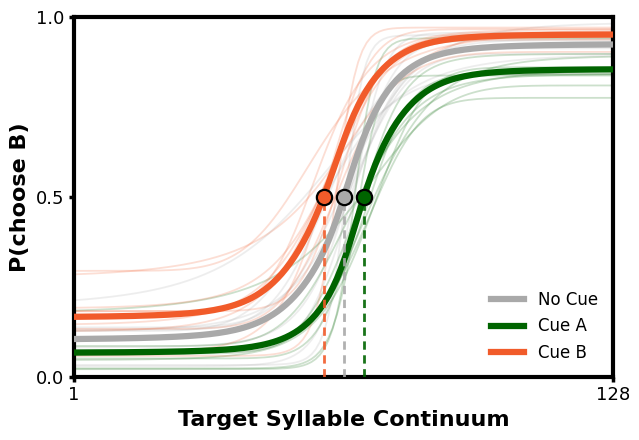

Saved to: /mnt/cube/jugorman/EDNpopdyn/for_github/figures/psychometric_curves.svg
Grand-average T50 (continuum units):
     No Cue: T50 = 64.6
      Cue A: T50 = 69.4
      Cue B: T50 = 59.8


In [15]:
MID_STYLE = "dot+line"

def _t50(x, y):

    y = np.asarray(y, float)
    above = y >= 0.5
    idx = np.where(np.diff(above.astype(int)) != 0)[0]
    if idx.size == 0:
        return np.nan
    i = idx[0]
    x0, x1, y0, y1 = x[i], x[i + 1], y[i], y[i + 1]
    if y1 == y0:
        return float(x0)
    return float(x0 + (0.5 - y0) / (y1 - y0) * (x1 - x0))

fig, ax = plt.subplots(figsize=(6.5, 4.5))

for c in cue_order:
    for b in birds:
        y = bird_curves[b][c]
        if y is None:
            continue
        ax.plot(x, y, color=cue_colors[c], linewidth=1.3, alpha=0.2)

for c in cue_order:
    if grand[c] is not None:
        ax.plot(x, grand[c], color=cue_colors[c], linewidth=4.5,
                label=cue_labels[c], zorder=4)

for c in cue_order:
    if grand[c] is None:
        continue
    t50 = _t50(x, grand[c])
    if not np.isfinite(t50):
        continue
    col = cue_colors[c]
    if MID_STYLE in ("dot", "dot+line"):
        if MID_STYLE == "dot+line":
            ax.vlines(t50, 0, 0.5, color=col, lw=2, ls=(0, (3, 2)), alpha=0.9, zorder=5)
        ax.plot(t50, 0.5, marker="o", ms=11, mfc=col, mec="k", mew=1.6, zorder=6)
    elif MID_STYLE == "arrow":

        ax.annotate("", xy=(t50, 0.5), xytext=(t50, 0.5 - 0.18),
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=2.5,
                                    mutation_scale=20), zorder=6)

ax.set_xlabel("Target Syllable Continuum", fontsize=16, fontweight="bold")
ax.set_ylabel("P(choose B)", fontsize=16, fontweight="bold")
ax.set_ylim(0, 1)
ax.set_xlim(x[0], x[-1])
ax.set_xticks([x[0], x[-1]])
ax.set_yticks([0, 0.5, 1])
for spine in ax.spines.values():
    spine.set_linewidth(3)
ax.tick_params(labelsize=13, width=2.5)
ax.legend(frameon=False, fontsize=12, loc="lower right")
plt.tight_layout()
plt.show()

out_path = f"{FIGURES_DIR}/psychometric_curves.svg"
fig.savefig(out_path, format="svg", bbox_inches="tight")
fig.savefig(out_path.replace(".svg", ".png"), format="png", dpi=200, bbox_inches="tight")
print("Saved to:", out_path)

print("Grand-average T50 (continuum units):")
for c in cue_order:
    if grand[c] is not None:
        print(f"  {cue_labels[c]:>9}: T50 = {_t50(x, grand[c]):.1f}")

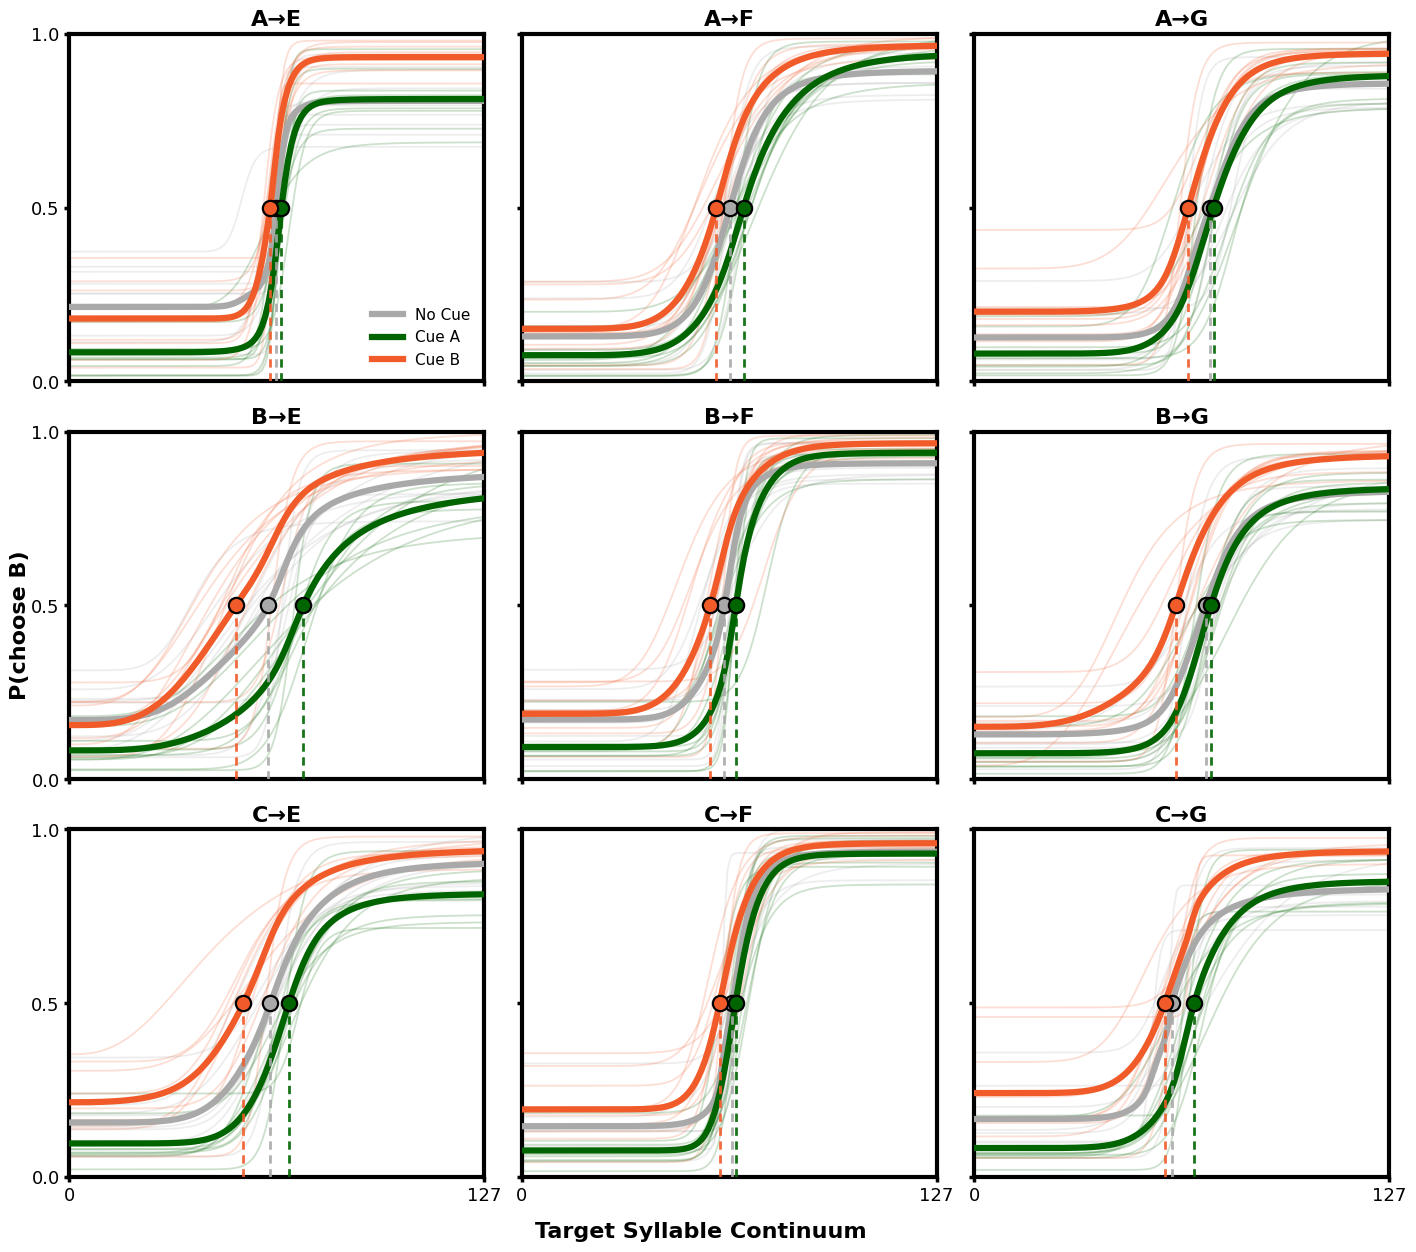

Grand-average T50 (continuum units):
continuum  T50_NC  n_NC  T50_CL  n_CL  T50_CR  n_CR
      A→E    63.4    10    64.9    10    61.5    10
      A→F    63.7    10    67.9    10    59.6    10
      A→G    72.0     9    73.3     9    65.5     9
      B→E    60.9    10    71.6    10    50.9    10
      B→F    62.0    10    65.5    10    57.7    10
      B→G    70.9     9    72.5     9    61.7     9
      C→E    61.6     9    67.2     9    53.3     9
      C→F    64.5     9    65.4     9    60.6     9
      C→G    60.7     9    67.4     9    58.3     9


In [16]:
MIN_TRIALS = 50
MID_STYLE  = "dot+line"
NCOLS      = 3
INTERP_MAX = 127
interp_range = np.arange(128)
x = interp_range

cue_order  = ["NC", "CL", "CR"]
cue_colors = {"NC": "darkgray", "CL": "darkgreen", "CR": pal.cue_cr}
cue_labels = {"NC": "No Cue", "CL": "Cue A", "CR": "Cue B"}

try:
    birds
except NameError:
    birds = list(behav_data.keys())

def _t50(x, y):
    y = np.asarray(y, float)
    above = y >= 0.5
    idx = np.where(np.diff(above.astype(int)) != 0)[0]
    if idx.size == 0:
        return np.nan
    i = idx[0]
    x0, x1, y0, y1 = x[i], x[i + 1], y[i], y[i + 1]
    return float(x0) if y1 == y0 else float(x0 + (0.5 - y0) / (y1 - y0) * (x1 - x0))

def _cue3(v):
    v = str(v)
    if v == "N" or v.startswith("N"):
        return "NC"
    if v.startswith("CL"):
        return "CL"
    if v.startswith("CR"):
        return "CR"
    return None

orient = {}
for b in birds:
    if b not in behav_data:
        continue
    d = behav_data[b]
    if "cue_id" not in d.columns:
        orient[b] = dict(flip_x=False, flip_y=False)
        continue
    s = d["cue_id"].map(_cue3)
    iR = d.loc[s == "CR", "interpolation_point"].mean()
    iL = d.loc[s == "CL", "interpolation_point"].mean()
    rR = d.loc[s == "CR", "response_bool"].mean()
    rL = d.loc[s == "CL", "response_bool"].mean()
    orient[b] = dict(
        flip_x=bool(np.isfinite(iR) and np.isfinite(iL) and iR < iL),
        flip_y=bool(np.isfinite(rR) and np.isfinite(rL) and rR < rL),
    )

need = ["left_stim", "right_stim", "interpolation_point", "response_bool", "cue_id"]
curves = {}
for b in birds:
    if b not in behav_data:
        continue
    d = behav_data[b]
    if any(c not in d.columns for c in need):
        continue
    d = d.dropna(subset=need).copy()
    if orient[b]["flip_x"]:
        d["interpolation_point"] = INTERP_MAX - d["interpolation_point"]
    if orient[b]["flip_y"]:
        d["response_bool"] = 1.0 - d["response_bool"]
    d["continuum"] = d["left_stim"].astype(str) + "→" + d["right_stim"].astype(str)
    d["cue3"] = d["cue_id"].map(_cue3)
    for (cont, cue), sub in d.groupby(["continuum", "cue3"]):
        if cue not in cue_order or len(sub) < MIN_TRIALS:
            continue
        xx = sub["interpolation_point"].to_numpy("float32")
        yy = sub["response_bool"].to_numpy("float32")
        try:
            (_min, _max, _infl, _slope), _, _, _ = fit_FourParameterLogistic(xx, yy)
            yi = np.asarray(FourParameterLogistic(
                {"_min": _min, "_max": _max, "inflection": _infl, "slope": _slope},
                interp_range), float)
        except Exception:
            continue
        curves.setdefault(cont, {}).setdefault(cue, {})[b] = yi

continua = sorted(curves.keys())
grand = {cont: {cue: (np.nanmean(np.vstack(list(curves[cont][cue].values())), axis=0)
                      if curves[cont].get(cue) else None)
                for cue in cue_order}
         for cont in continua}

n = len(continua)
ncols = NCOLS
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.2 * nrows),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).flatten()

for pi, (ax, cont) in enumerate(zip(axes, continua)):
    for cue in cue_order:
        for b, yb in curves[cont].get(cue, {}).items():
            ax.plot(x, yb, color=cue_colors[cue], linewidth=1.3, alpha=0.2, zorder=2)
    for cue in cue_order:
        g = grand[cont][cue]
        if g is None:
            continue
        ax.plot(x, g, color=cue_colors[cue], linewidth=4.5,
                label=cue_labels[cue], zorder=4)
        t50 = _t50(x, g)
        if np.isfinite(t50):
            col = cue_colors[cue]
            if MID_STYLE in ("dot", "dot+line"):
                if MID_STYLE == "dot+line":
                    ax.vlines(t50, 0, 0.5, color=col, lw=2, ls=(0, (3, 2)), alpha=0.9, zorder=5)
                ax.plot(t50, 0.5, marker="o", ms=11, mfc=col, mec="k", mew=1.6, zorder=6)
    ax.set_title(cont, fontsize=16, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.set_xlim(x[0], x[-1])
    ax.set_xticks([x[0], x[-1]])
    ax.set_yticks([0, 0.5, 1])
    for spine in ax.spines.values():
        spine.set_linewidth(3)
    ax.tick_params(labelsize=13, width=2.5)
    if pi == 0:
        ax.legend(frameon=False, fontsize=11, loc="lower right")

for ax in axes[n:]:
    ax.set_visible(False)

fig.supxlabel("Target Syllable Continuum", fontsize=16, fontweight="bold")
fig.supylabel("P(choose B)", fontsize=16, fontweight="bold")
fig.tight_layout()

out_path = f"{FIGURES_DIR}/psychometric_per_continuum_cuebreakdown.svg"
fig.savefig(out_path, format="svg", bbox_inches="tight")
fig.savefig(out_path.replace(".svg", ".png"), format="png", dpi=200, bbox_inches="tight")
plt.show()

print("Grand-average T50 (continuum units):")
rows = []
for cont in continua:
    r = {"continuum": cont}
    for cue in cue_order:
        g = grand[cont][cue]
        r[f"T50_{cue}"] = _t50(x, g) if g is not None else np.nan
        r[f"n_{cue}"] = len(curves[cont].get(cue, {}))
    rows.append(r)
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.1f}"))

In [17]:
import numpy as np, pandas as pd
from scipy.stats import wilcoxon

REF = "NC"
CONTRASTS = ["CR", "CL"]

recs = []
for cont in continua:
    for cue in cue_order:
        for b, yb in curves[cont].get(cue, {}).items():
            recs.append(dict(continuum=cont, cue=cue, bird=b, t50=_t50(x, yb)))
t50_df = pd.DataFrame(recs)

per_cont, pooled = [], {c: [] for c in CONTRASTS}
for cont, g in t50_df.groupby("continuum"):
    w = g.pivot_table(index="bird", columns="cue", values="t50")
    row = {"continuum": cont, "n_birds_NC": int(w[REF].notna().sum()) if REF in w else 0}
    for cue in CONTRASTS:
        if cue in w and REF in w:
            d = (w[cue] - w[REF]).dropna().to_numpy(float)
        else:
            d = np.array([])
        row[f"n_{cue}"] = len(d)
        row[f"dT50_{cue}_minus_NC_median"] = float(np.median(d)) if len(d) else np.nan
        if len(d) >= 3 and np.any(d != 0):
            W, p = wilcoxon(d)
            row[f"p_{cue}"] = float(p)
        else:
            row[f"p_{cue}"] = np.nan
        pooled[cue].extend(d.tolist())
    per_cont.append(row)
per_cont_df = pd.DataFrame(per_cont)

pooled_rows = []
for cue in CONTRASTS:
    d = np.array(pooled[cue], float); d = d[np.isfinite(d)]
    if len(d) >= 3 and np.any(d != 0):
        W, p = wilcoxon(d)
    else:
        W, p = np.nan, np.nan
    pooled_rows.append(dict(contrast=f"{cue}-NC", n_bird_x_continuum=len(d),
                            median_dT50=float(np.median(d)) if len(d) else np.nan,
                            wilcoxon_W=float(W) if np.isfinite(W) else np.nan,
                            p=float(p) if np.isfinite(p) else np.nan))
pooled_df = pd.DataFrame(pooled_rows)

print("=== Per-continuum cue-induced T50 shift (vs NC) ===")
print(per_cont_df.to_string(index=False, float_format=lambda v: f"{v:.3g}"))
print("\n=== POOLED across continua (quote this in the caption) ===")
print(pooled_df.to_string(index=False, float_format=lambda v: f"{v:.3g}"))

per_cont_df.to_csv(f"{STATS_CSV_DIR}/psychometric_continuum_T50_shifts.csv", index=False)
pooled_df.to_csv(f"{STATS_CSV_DIR}/psychometric_T50_shifts_pooled.csv", index=False)

panel_note = {}
for _, r in per_cont_df.iterrows():
    panel_note[r["continuum"]] = (f"ΔCR={r['dT50_CR_minus_NC_median']:+.0f}  "
                                  f"ΔCL={r['dT50_CL_minus_NC_median']:+.0f}")

=== Per-continuum cue-induced T50 shift (vs NC) ===
continuum  n_birds_NC  n_CR  dT50_CR_minus_NC_median    p_CR  n_CL  dT50_CL_minus_NC_median    p_CL
      A→E          10    10                    -1.95   0.084    10                     1.53 0.00195
      A→F          10    10                    -5.06 0.00195    10                     5.23 0.00195
      A→G           9     9                    -6.97 0.00391     9                     2.32    0.25
      B→E          10    10                    -9.05  0.0195    10                     17.7 0.00195
      B→F          10    10                    -4.16   0.084    10                     4.71 0.00195
      B→G           9     9                     -8.6 0.00391     9                     2.91   0.164
      C→E           9     9                    -8.96 0.00781     9                     5.53 0.00391
      C→F           9     9                    -4.63  0.0273     9                    0.945   0.301
      C→G           9     9                    -

In [18]:
import numpy as np, pandas as pd

MID         = 64
AMBIG_BAND  = 0
INTERP_MAX  = 127

try:
    birds
except NameError:
    birds = list(behav_data.keys())

def _cue_side(v):
    v = str(v)
    if v.startswith("CR"):
        return "right"
    if v.startswith("CL"):
        return "left"
    if v == "N" or v.startswith("N"):
        return "nocue"
    return None

rows = []
for b in birds:
    if b not in behav_data:
        continue
    d = behav_data[b]
    if not {"interpolation_point", "cue_id"}.issubset(d.columns):
        continue
    d = d.dropna(subset=["interpolation_point", "cue_id"]).copy()
    d["cue_side"] = d["cue_id"].map(_cue_side)

    iR = d.loc[d.cue_side == "right", "interpolation_point"].mean()
    iL = d.loc[d.cue_side == "left",  "interpolation_point"].mean()
    flip_x = bool(np.isfinite(iR) and np.isfinite(iL) and iR < iL)
    interp = (INTERP_MAX - d["interpolation_point"]) if flip_x else d["interpolation_point"]

    keep = (np.abs(interp - MID) >= AMBIG_BAND) if AMBIG_BAND else np.ones(len(d), bool)
    stim_side = np.where(interp >= MID, "right", "left")

    cued = d.cue_side.isin(["left", "right"]) & keep
    match = (d.cue_side == stim_side)
    n_total   = len(d)
    n_nocue   = int((d.cue_side == "nocue").sum())
    n_valid   = int((cued & match).sum())
    n_invalid = int((cued & ~match).sum())
    rows.append(dict(bird=b, flip_x=flip_x, total=n_total, no_cue=n_nocue,
                     cued=n_valid + n_invalid, valid=n_valid, invalid=n_invalid,
                     pct_valid=100 * n_valid / max(n_valid + n_invalid, 1)))

tbl = pd.DataFrame(rows)

T   = int(tbl["total"].sum())
NC  = int(tbl["no_cue"].sum())
V   = int(tbl["valid"].sum())
INV = int(tbl["invalid"].sum())
CUED = V + INV

print("=" * 60)
print(f"TOTAL trials across all birds : {T:,}   (n_birds = {len(tbl)})")
print(f"  no-cue trials               : {NC:,}  ({100*NC/T:.1f}% of total)")
print(f"  cued trials                 : {CUED:,}  ({100*CUED/T:.1f}% of total)")
print(f"     valid   (cue matches side): {V:,}  ({100*V/CUED:.1f}% of cued)")
print(f"     invalid (cue mismatches)  : {INV:,}  ({100*INV/CUED:.1f}% of cued)")
print("=" * 60)
print("\nPer-bird breakdown:")
print(tbl.to_string(index=False, float_format=lambda v: f"{v:.1f}"))

tbl.to_csv(f"{STATS_CSV_DIR}/trial_counts_valid_invalid.csv",
           index=False)

TOTAL trials across all birds : 2,539,216   (n_birds = 10)
  no-cue trials               : 530,814  (20.9% of total)
  cued trials                 : 1,904,110  (75.0% of total)
     valid   (cue matches side): 1,533,278  (80.5% of cued)
     invalid (cue mismatches)  : 370,832  (19.5% of cued)

Per-bird breakdown:
 bird  flip_x  total  no_cue   cued  valid  invalid  pct_valid
B1170    True 520304  105551 394841 314022    80819       79.5
B1248   False  91821   14480  73664  59960    13704       81.4
B1597    True  33216    5337  26669  21626     5043       81.1
B1595   False  98607   34259  55995  45667    10328       81.6
B1188    True  74724   44533  28812  23450     5362       81.4
B1244    True 235092   57708 169011 137262    31749       81.2
B1276   False 170278   38009 122778  99816    22962       81.3
B1426    True 394956   73749 305656 243476    62180       79.7
B1432    True 769387  133619 605518 489483   116035       80.8
B1593   False 150831   23569 121166  98516    22650   

In [19]:
def _pick_col(df, names):
    for n in names:
        if n in df.columns: return n
    return None

def _coerce_right(col):
    s = pd.Series(col).copy()

    if np.issubdtype(s.dropna().dtype, np.number):

        u = set(pd.unique(s.dropna()))
        if u <= {0,1}: return s.astype(int)
        if u <= {1,2}: return s.map({1:0, 2:1}).astype(int)
        if len(u)==2:
            hi = max(u); return (s==hi).astype(int)

    s = s.astype(str).str.strip().str.lower()
    right = {'right','r','peck_right','peck right','category right','cr','cue right','cue_right','true','t','yes','y','1'}
    left  = {'left','l','peck_left','peck left','category left','cl','cue left','cue_left','false','f','no','n','0'}
    out = pd.Series(np.nan, index=s.index, dtype='float64')
    out[s.isin(right)] = 1
    out[s.isin(left)]  = 0

    out = out.fillna(s.str.contains('right').astype(float))
    out[s.str.contains('left')] = 0
    return out.astype(float)

def _normalize_cue(x):
    x = str(x).strip().upper()
    if x in {'NC','NO CUE','NONE','NOCUE','NO_CUE'}: return 'NC'
    if x.startswith('CL') or x in {'L','LEFT'}:      return 'CL'
    if x.startswith('CR') or x in {'R','RIGHT'}:     return 'CR'
    return np.nan

def _fit_t50(stim, choice):

    stim = np.asarray(stim, float)
    y    = np.asarray(choice, int)
    ok = np.isfinite(stim) & np.isfinite(y)
    stim = stim[ok]; y = y[ok]
    if stim.size < 20 or len(np.unique(y)) < 2 or len(np.unique(stim)) < 4:
        return np.nan
    x = (stim - stim.min()) / max(1e-9, (stim.max() - stim.min()))
    X = x.reshape(-1,1)

    clf = LogisticRegression(
        penalty='l2', C=1.0, solver='lbfgs', max_iter=2000
    )
    try:
        clf.fit(X, y)
    except Exception:
        return np.nan
    w = float(clf.coef_[0,0]); b = float(clf.intercept_[0])

    if abs(w) < 1e-12:
        return np.nan
    x_star = -b / w

    return float(stim.min() + x_star * (stim.max() - stim.min()))

def build_session_t50s(behav_data, birds_subset=None, min_trials_per_cue=30):
    rows = []
    for bird, df in behav_data.items():
        if (birds_subset is not None) and (bird not in birds_subset):
            continue
        if not isinstance(df, pd.DataFrame) or df.empty:
            continue

        sess_col = _pick_col(df, ['session','sess','session_id','data_file'])
        stim_col = _pick_col(df, ['interpolation_point','pos_bin','interpolation'])
        cue_col  = _pick_col(df, ['cue_class','cueing','cue_id','cue_direction','cue','type_'])
        resp_col = _pick_col(df, ['binary_choice','response_bool','choice','response'])

        if any(c is None for c in [sess_col, stim_col, cue_col, resp_col]):
            continue

        sub = df[[sess_col, stim_col, cue_col, resp_col]].copy()
        sub.columns = ['session','stim','cue_raw','resp_raw']

        sub['stim'] = pd.to_numeric(sub['stim'], errors='coerce')
        sub = sub[(sub['stim']>=1) & (sub['stim']<=128)]

        sub['cue'] = sub['cue_raw'].map(_normalize_cue)

        sub['right'] = _coerce_right(sub['resp_raw'])

        good = np.isfinite(sub['stim']) & sub['cue'].isin(['NC','CL','CR']) & np.isfinite(sub['right'])
        sub = sub.loc[good, ['session','stim','cue','right']]

        for session, g in sub.groupby('session'):
            for cue in ['NC','CL','CR']:
                gg = g[g['cue']==cue]
                if len(gg) < min_trials_per_cue:
                    t50 = np.nan
                else:
                    t50 = _fit_t50(gg['stim'].values, gg['right'].values)
                rows.append(dict(bird=bird, session=session, cue=cue, n=len(gg), T50=t50))
    t50_df = pd.DataFrame(rows)
    return t50_df

def paired_session_stats(t50_df):

    pivot = t50_df.pivot_table(index=['bird','session'], columns='cue', values='T50', aggfunc='first')
    out = {}

    for pair, label, direction in [(('CL','NC'), 'CL−NC', 'two-sided'),
                                   (('CR','NC'), 'CR−NC', 'two-sided')]:
        a, b = pair
        keep = pivot[[a,b]].dropna()
        if keep.empty:
            out[label] = dict(n=0, mean=np.nan, sem=np.nan, W=np.nan, p=np.nan)
            continue
        d = keep[a].values - keep[b].values

        try:
            W, p = wilcoxon(d)
        except ValueError:

            W, p = 0.0, 1.0
        mean = float(np.mean(d))
        sem  = float(np.std(d, ddof=1)/np.sqrt(len(d))) if len(d)>1 else np.nan
        out[label] = dict(n=len(d), mean=mean, sem=sem, W=float(W), p=float(p))
    return out

t50_df = build_session_t50s(behav_data, birds_subset=None, min_trials_per_cue=30)
stats = paired_session_stats(t50_df)

print("Per-session T50 stats (Δ = cue − NC; continuum units):")
for k, v in stats.items():
    print(f"{k}: n={v['n']}, Δ={v['mean']:.2f} ± {v['sem']:.2f}, Wilcoxon W={v['W']:.3g}, p={v['p']:.3g}")

if stats['CL−NC']['n']>0:
    print(f"CL shifts threshold toward A (ΔT50 = {stats['CL−NC']['mean']:.2f} ± {stats['CL−NC']['sem']:.2f}; "
          f"Wilcoxon W={stats['CL−NC']['W']:.3g}, p={stats['CL−NC']['p']:.3g}, n={stats['CL−NC']['n']} sessions).")
if stats['CR−NC']['n']>0:
    print(f"CR shifts threshold toward B (ΔT50 = {stats['CR−NC']['mean']:.2f} ± {stats['CR−NC']['sem']:.2f}; "
          f"Wilcoxon W={stats['CR−NC']['W']:.3g}, p={stats['CR−NC']['p']:.3g}, n={stats['CR−NC']['n']} sessions).")

Per-session T50 stats (Δ = cue − NC; continuum units):
CL−NC: n=391, Δ=33.67 ± 10.59, Wilcoxon W=2.41e+04, p=1.87e-10
CR−NC: n=392, Δ=-4.41 ± 7.52, Wilcoxon W=3.37e+04, p=0.0336
CL shifts threshold toward A (ΔT50 = 33.67 ± 10.59; Wilcoxon W=2.41e+04, p=1.87e-10, n=391 sessions).
CR shifts threshold toward B (ΔT50 = -4.41 ± 7.52; Wilcoxon W=3.37e+04, p=0.0336, n=392 sessions).


## 4) Mean inflection points and shift by cue

=== Inflection summary (across birds) ===
NC: mean=64.36 ± 1.13 (n=10)
CL: mean=68.91 ± 0.60 (n=10)
CR: mean=61.38 ± 0.74 (n=10)


/tmp/ipykernel_1288179/1968867539.py:89: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


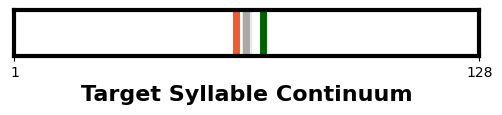

Saved to: /mnt/cube/jugorman/EDNpopdyn/for_github/figures/inflection_vertical_lines.svg

=== Paired within-bird tests on inflection positions ===
CR − NC: Δ=-2.98 ± 1.05 (mean±SEM, n=10); Wilcoxon W=7, p=0.0371
CL − NC: Δ=4.55 ± 0.96 (mean±SEM, n=10); Wilcoxon W=0, p=0.00195


In [20]:
birds = ["B1170", "B1248", "B1597", "B1595", "B1188", "B1244", "B1276", "B1426", "B1432", "B1593"]
cue_colors = {"NC":"darkgray", "CL":"darkgreen", "CR":pal.cue_cr}
continuum_min, continuum_max = 1, 128
apply_orientation_alignment = True
sem_band = True

def _sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0: return np.nan
    return np.std(x, ddof=1) / np.sqrt(x.size)

def _bird_nc_is_decreasing(df_bird):

    try:
        nc_rows = df_bird[df_bird["cue"] == "NC"]
        if nc_rows.empty:
            return False
        y = np.asarray(nc_rows.iloc[0]["y_interp"], float)
        if y.ndim != 1 or y.size < 6:
            return False
        w = max(5, y.size // 10)
        return (np.nanmean(y[-w:]) - np.nanmean(y[:w])) < 0
    except Exception:
        return False

def _flip_inflection(x, lo=1, hi=128):

    return (lo + hi) - x

per_bird_inflections = {b: {"NC": np.nan, "CL": np.nan, "CR": np.nan} for b in birds}

for b in birds:
    df_b = fit_df[fit_df["bird"] == b].copy()
    if df_b.empty:
        continue

    do_flip = apply_orientation_alignment and _bird_nc_is_decreasing(df_b)

    inf_nc = df_b.loc[df_b["cue"] == "NC", "_inflection"].to_numpy(dtype=float)
    inf_cl = df_b.loc[df_b["cue"].isin(["CL0","CL1"]), "_inflection"].to_numpy(dtype=float)
    inf_cr = df_b.loc[df_b["cue"].isin(["CR0","CR1"]), "_inflection"].to_numpy(dtype=float)

    if do_flip:
        inf_nc = (continuum_min + continuum_max) - inf_nc
        inf_cl = (continuum_min + continuum_max) - inf_cl
        inf_cr = (continuum_min + continuum_max) - inf_cr

    if inf_nc.size: per_bird_inflections[b]["NC"] = float(np.nanmean(inf_nc))
    if inf_cl.size: per_bird_inflections[b]["CL"] = float(np.nanmean(inf_cl))
    if inf_cr.size: per_bird_inflections[b]["CR"] = float(np.nanmean(inf_cr))

NC_vals = np.array([per_bird_inflections[b]["NC"] for b in birds], float)
CL_vals = np.array([per_bird_inflections[b]["CL"] for b in birds], float)
CR_vals = np.array([per_bird_inflections[b]["CR"] for b in birds], float)

def _mean_and_sem(arr):
    arr = arr[np.isfinite(arr)]
    if arr.size == 0: return np.nan, np.nan, 0
    return float(np.mean(arr)), float(_sem(arr)), int(arr.size)

mean_NC, sem_NC, n_NC = _mean_and_sem(NC_vals)
mean_CL, sem_CL, n_CL = _mean_and_sem(CL_vals)
mean_CR, sem_CR, n_CR = _mean_and_sem(CR_vals)

print("=== Inflection summary (across birds) ===")
print(f"NC: mean={mean_NC:.2f} ± {sem_NC:.2f} (n={n_NC})")
print(f"CL: mean={mean_CL:.2f} ± {sem_CL:.2f} (n={n_CL})")
print(f"CR: mean={mean_CR:.2f} ± {sem_CR:.2f} (n={n_CR})")

fig, ax = plt.subplots(figsize=(6, 0.6))

def _vline_with_sem(x0, m, s, color, label=None, show_band=True):
    ax.axvline(x=m, color=color, linewidth=5, label=label)
    if show_band and np.isfinite(s) and s > 0:
        ax.axvspan(m - s, m + s, color=color, alpha=0.2)

for cue, m, s in [("NC", mean_NC, sem_NC), ("CL", mean_CL, sem_CL), ("CR", mean_CR, sem_CR)]:
    if np.isfinite(m):
        _vline_with_sem(cue, m, s, cue_colors[cue], label=f"{cue}", show_band=sem_band)

ax.set_xlabel("Target Syllable Continuum", fontsize=16, fontweight="bold")
ax.set_xlim(continuum_min, continuum_max)
ax.set_xticks([continuum_min, continuum_max])
ax.set_yticks([]); ax.set_ylabel("")
for spine in ax.spines.values():
    spine.set_linewidth(3)

plt.tight_layout()
plt.show()


out_dir = f"{FIGURES_DIR}"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, "inflection_vertical_lines.svg")

fig.savefig(out_path, format="svg", bbox_inches="tight")

print("Saved to:", out_path)

from scipy.stats import wilcoxon
def paired_wilcoxon_clean(a, b, label):
    mask = np.isfinite(a) & np.isfinite(b)
    if np.sum(mask) < 3:
        print(f"{label}: too few birds with both values (n={np.sum(mask)})")
        return
    W, p = wilcoxon(a[mask], b[mask])
    d = (a[mask] - b[mask])
    print(f"{label}: Δ={np.mean(d):.2f} ± {np.std(d, ddof=1)/np.sqrt(d.size):.2f} (mean±SEM, n={d.size}); Wilcoxon W={W:.3g}, p={p:.3g}")

print("\n=== Paired within-bird tests on inflection positions ===")
paired_wilcoxon_clean(CR_vals, NC_vals, "CR − NC")
paired_wilcoxon_clean(CL_vals, NC_vals, "CL − NC")